In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, RocCurveDisplay
)
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv(r'D:\PROJECTS\customer-churn-prediction\merged_features.csv')
print(f'Shape: {df.shape}')
print(f'Churn rate: {df["is_churn"].mean():.2%}')

Shape: (970960, 47)
Churn rate: 8.99%


In [4]:
X = df.drop(columns=['is_churn'])
y = df['is_churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,          # keeps churn rate equal in both splits
    random_state=42
)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train churn rate: {y_train.mean():.2%}')
print(f'Test churn rate:  {y_test.mean():.2%}')

Train: (776768, 46)  |  Test: (194192, 46)
Train churn rate: 8.99%
Test churn rate:  8.99%


In [7]:
# Add this between Cell 2 (split) and Cell 4 (fit)
# Check all dtypes — find any non-numeric columns
bad_cols = X_train.select_dtypes(exclude=['int64', 'float64', 'bool']).columns.tolist()
print('Non-numeric columns:', bad_cols)

Non-numeric columns: ['last_expire']


In [8]:
# Drop date string columns — not useful as raw strings
cols_to_drop = ['last_expire']   # add any others that show up above
X_train = X_train.drop(columns=cols_to_drop, errors='ignore')
X_test  = X_test.drop(columns=cols_to_drop, errors='ignore')

print(f'X_train shape after drop: {X_train.shape}')
print('Remaining dtypes check:', X_train.select_dtypes(exclude=['int64','float64','bool']).columns.tolist())
# Should print: []

X_train shape after drop: (776768, 45)
Remaining dtypes check: []


In [9]:
# scale_pos_weight tells LightGBM how much more to penalize 
# missing a churn prediction vs a non-churn prediction
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f'Negative (renewed): {neg:,}')
print(f'Positive (churned): {pos:,}')
print(f'scale_pos_weight:   {scale_pos_weight:.2f}')
# Expect ~13-15x — this is correct, don't worry about the size

Negative (renewed): 706,904
Positive (churned): 69,864
scale_pos_weight:   10.12


In [10]:
model = lgb.LGBMClassifier(
    n_estimators      = 1000,    # high ceiling — early stopping will cut this down
    learning_rate     = 0.05,
    num_leaves        = 63,
    min_child_samples = 20,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = scale_pos_weight,
    random_state      = 42,
    n_jobs            = -1,
    # device          = 'gpu',   # uncomment if you want GPU — yours has 4GB which is fine
)

model.fit(
    X_train, y_train,
    eval_set           = [(X_test, y_test)],
    eval_metric        = 'auc',
    callbacks          = [
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=100)
    ]
)

print(f'\nBest iteration: {model.best_iteration_}')

[LightGBM] [Info] Number of positive: 69864, number of negative: 706904
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.037666 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1568
[LightGBM] [Info] Number of data points in the train set: 776768, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.089942 -> initscore=-2.314344
[LightGBM] [Info] Start training from score -2.314344
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[40]	valid_0's auc: 0.978883	valid_0's binary_logloss: 0.162631

Best iteration: 40


In [11]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred       = model.predict(X_test)

auc = roc_auc_score(y_test, y_pred_proba)
print(f'ROC-AUC: {auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Renewed', 'Churned']))

ROC-AUC: 0.9789

              precision    recall  f1-score   support

     Renewed       0.99      0.96      0.97    176726
     Churned       0.70      0.88      0.78     17466

    accuracy                           0.96    194192
   macro avg       0.84      0.92      0.88    194192
weighted avg       0.96      0.96      0.96    194192



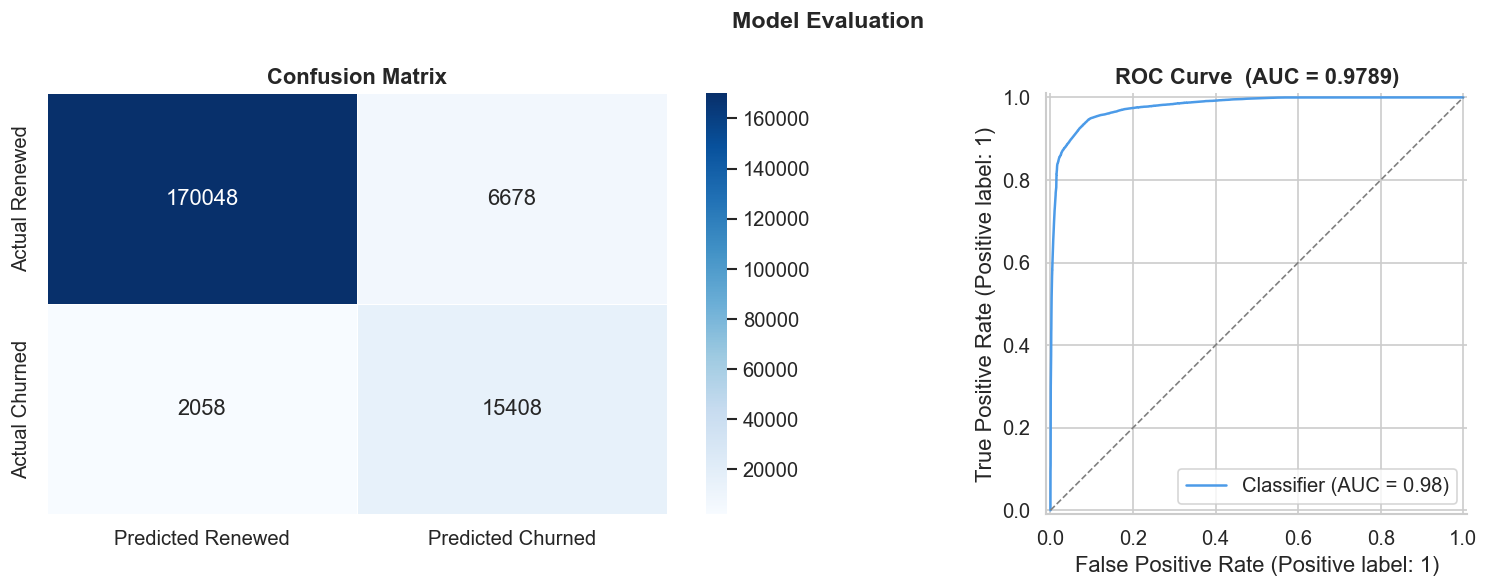

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted Renewed', 'Predicted Churned'],
    yticklabels=['Actual Renewed', 'Actual Churned'],
    ax=axes[0], linewidths=0.5
)
axes[0].set_title('Confusion Matrix', fontweight='bold')

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[1], color='#4C9BE8')
axes[1].plot([0,1],[0,1],'--', color='gray', linewidth=1)
axes[1].set_title(f'ROC Curve  (AUC = {auc:.4f})', fontweight='bold')

plt.suptitle('Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_model_evaluation.png', bbox_inches='tight')
plt.show()

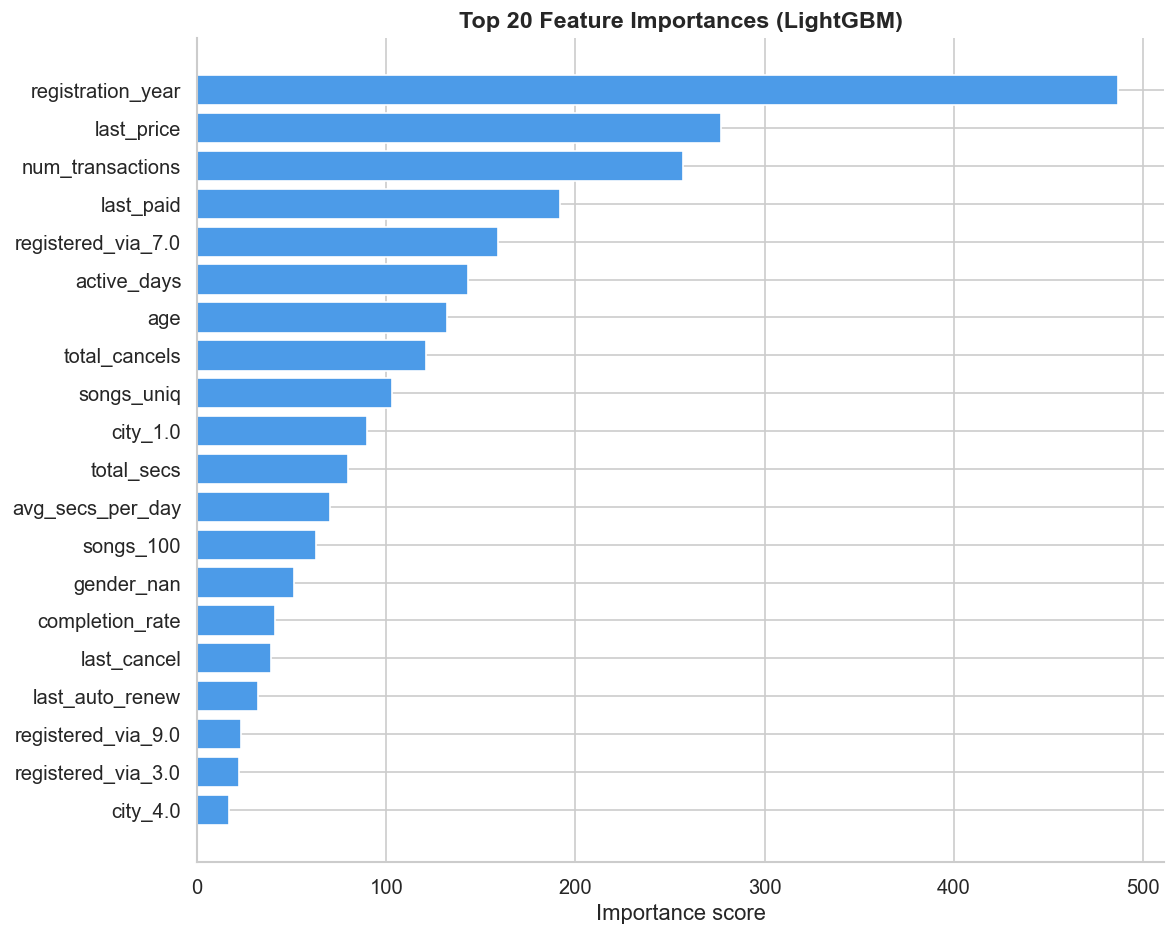

           feature  importance
 registration_year         487
        last_price         277
  num_transactions         257
         last_paid         192
registered_via_7.0         159
       active_days         143
               age         132
     total_cancels         121
        songs_uniq         103
          city_1.0          90
        total_secs          80
  avg_secs_per_day          70
         songs_100          63
        gender_nan          51
   completion_rate          41
       last_cancel          39
   last_auto_renew          32
registered_via_9.0          23
registered_via_3.0          22
          city_4.0          17


In [13]:
importance_df = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(
    importance_df['feature'][::-1],
    importance_df['importance'][::-1],
    color='#4C9BE8', edgecolor='white'
)
ax.set_title('Top 20 Feature Importances (LightGBM)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', bbox_inches='tight')
plt.show()

print(importance_df.to_string(index=False))

In [14]:
import joblib

joblib.dump(model, r'D:\PROJECTS\customer-churn-prediction\kkbox_lgbm_model.pkl')
print('Model saved.')

# To reload later:
# model = joblib.load(r'D:\PROJECTS\customer-churn-prediction\kkbox_lgbm_model.pkl')

Model saved.


In [15]:
import matplotlib.pyplot as plt

# See how registration_year correlates with churn
churn_by_year = df.groupby('registration_year')['is_churn'].mean() * 100
print(churn_by_year.sort_values(ascending=False))

# Also check the range — is there anything suspicious?
print(df['registration_year'].value_counts().sort_index())

registration_year
2010.0    11.638199
2017.0    11.534758
2009.0    11.086390
2014.0    10.580755
2013.0    10.162723
2008.0    10.042409
2012.0     9.622122
2007.0     9.045034
2016.0     8.848061
2004.0     8.787515
2011.0     8.784474
2015.0     8.561564
2006.0     8.139406
2005.0     6.807121
0.0        5.347613
Name: is_churn, dtype: float64
registration_year
0.0       109993
2004.0      8330
2005.0     15616
2006.0     18048
2007.0     26158
2008.0     17685
2009.0     15731
2010.0     38640
2011.0     60698
2012.0     74495
2013.0    113444
2014.0     89332
2015.0    154376
2016.0    195184
2017.0     33230
Name: count, dtype: int64
